# # Cálculo de Densidad desde un Archivo GSD (HOOMD-blue)

In [1]:
# 1. Importar las librerías necesarias
import gsd.hoomd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
archivo_gsd = "/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Polymers/P2_Polimero_Solvente/traj_Poly-Solv_T0.70_epsSP0.10.gsd"

In [3]:
pasos = []
densidades = []
volúmenes = []

print(f"Abriendo archivo: {archivo_gsd}")

with gsd.hoomd.open(name=archivo_gsd, mode='r') as trayectoria:
    total_frames = len(trayectoria)
    print(f"Total de frames detectados: {total_frames}")
    
    for i, frame in enumerate(trayectoria):
        # Número total de partículas en este frame
        N = frame.particles.N
        
        # Obtener las dimensiones de la caja [lx, ly, lz, xy, xz, yz]
        lx, ly, lz = frame.configuration.box[0:3]
        
        # Calcular el volumen de la caja
        volumen = lx * ly * lz
        
        # Calcular la densidad de número (rho = N / V)
        rho = N / volumen
        
        # Guardar los datos (usamos el timestep real de la simulación si está disponible)
        pasos.append(frame.configuration.step)
        densidades.append(rho)
        volúmenes.append(volumen)
        
        # Imprimir progreso cada cierto tiempo para no saturar la pantalla
        if i % max(1, total_frames // 5) == 0 or i == total_frames - 1:
            print(f"Frame {i:4d} | Paso: {frame.configuration.step:7d} | N = {N} | Vol = {volumen:.2f} | Densidad = {rho:.5f}")

# Convertir listas a arreglos de NumPy para facilitar el análisis
pasos = np.array(pasos)
densidades = np.array(densidades)

Abriendo archivo: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Polymers/P2_Polimero_Solvente/traj_Poly-Solv_T0.70_epsSP0.10.gsd
Total de frames detectados: 1
Frame    0 | Paso:       1 | N = 1200000 | Vol = 31250000.00 | Densidad = 0.03840


In [4]:
print("\n--- ESTADÍSTICAS DE LA DENSIDAD ---")
print(f"Densidad Inicial: {densidades[0]:.5f}")
print(f"Densidad Final  : {densidades[-1]:.5f}")
print(f"Densidad Media  : {np.mean(densidades):.5f} ± {np.std(densidades):.5f}")


--- ESTADÍSTICAS DE LA DENSIDAD ---
Densidad Inicial: 0.03840
Densidad Final  : 0.03840
Densidad Media  : 0.03840 ± 0.00000


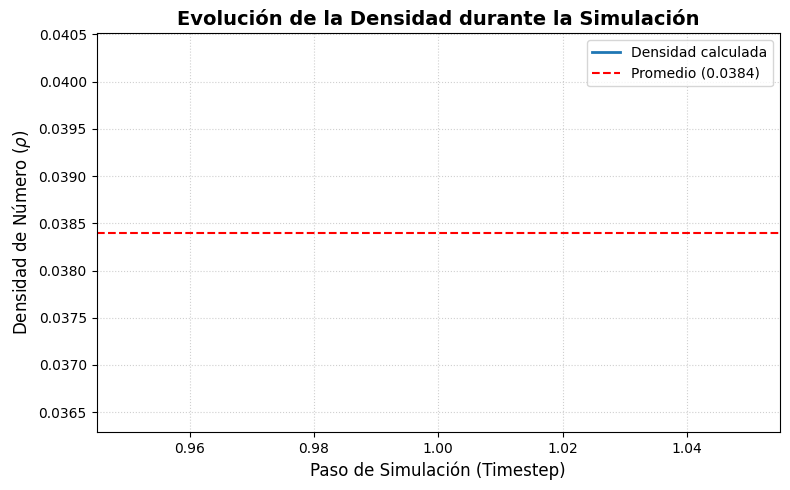

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(pasos, densidades, color='#1f77b4', linewidth=2, label='Densidad calculada')
plt.axhline(y=np.mean(densidades), color='r', linestyle='--', label=f'Promedio ({np.mean(densidades):.4f})')

plt.title('Evolución de la Densidad durante la Simulación', fontsize=14, fontweight='bold')
plt.xlabel('Paso de Simulación (Timestep)', fontsize=12)
plt.ylabel('Densidad de Número ($\\rho$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best')

# Ajustar los márgenes y mostrar la gráfica en el notebook
plt.tight_layout()
plt.show()